<a href="https://colab.research.google.com/github/vedant331/Credit-Prediction/blob/main/Credit_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Credit Risk Prediction System***
Predict whether a customer will repay loan or default.

In [ ]:
import psutil

ram = psutil.virtual_memory()
print(f"RAM Used: {ram.percent}%")
print(f"Available: {ram.available / (1024**3):.2f} GB")

RAM Used: 7.1%
Available: 11.77 GB


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_head = pd.read_csv(
    '/content/drive/MyDrive/Credit-Prediction/accepted_2007_to_2018Q4.csv.gz',
    compression='gzip',
    nrows=1
)

all_cols = df_head.columns.tolist()

drop_cols = [
    'id',
    'member_id',
    'url',
    'desc',
    'emp_title',
    'title',
    'pymnt_plan'
]

keep_cols = [c for c in all_cols if c not in drop_cols]

In [ ]:
df_head

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/Credit-Prediction/accepted_2007_to_2018Q4.csv.gz',
    compression='gzip',
    usecols=keep_cols
)

/tmp/ipykernel_8191/587009834.py:1: DtypeWarning: Columns (49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [ ]:
pd.options.display.max_columns = None

In [ ]:
print(df.shape)

(2260701, 144)


In [ ]:
print(df.columns.to_list())

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il

In [ ]:
df.isnull().sum()

,0
id,0
loan_amnt,33
funded_amnt,33
funded_amnt_inv,33
term,33
...,...
settlement_status,2226455
settlement_date,2226455
settlement_amount,2226455
settlement_percentage,2226455


In [ ]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,N

In [ ]:
df.columns.values

array(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan',
       'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'fico_range_low',
       'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
       'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'last_fico_range_high', 'last_fico_range_low',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'po

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


#**Going one by one through columns**

In [ ]:
# # dropping member_id column bcz of all null values

# df = df.drop('member_id',axis=1)
# df.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [ ]:
# checking ids
df['id'].isnull().sum()

#duplicated ids
df['id'].duplicated().sum()

np.int64(0)

In [ ]:
# checking loan_amnt

df['loan_amnt'].isnull().sum()

# finding median

median_loan_amt = df['loan_amnt'].median()
print(median_loan_amt)

12900.0


loan_amnt had only 33 missing values (0.0165% of records). Due to the negligible proportion of missing data, these rows were removed instead of imputing values.

In [ ]:
df = df.dropna(subset=['loan_amnt'])
df['loan_amnt'].isnull().sum()

np.int64(0)

In [ ]:
# # droppping id column

# df = df.drop('id',axis=1)

In [ ]:
# print(df.isnull().sum().to_string())

id                                                  0
loan_amnt                                           0
funded_amnt                                         0
funded_amnt_inv                                     0
term                                                0
int_rate                                            0
installment                                         0
grade                                               0
sub_grade                                           0
emp_title                                      166969
emp_length                                     146907
home_ownership                                      0
annual_inc                                          4
verification_status                                 0
issue_d                                             0
loan_status                                         0
pymnt_plan                                          0
url                                                 0
desc                        

In [ ]:
# df['url'].head()
# df['desc'].isnull().sum()

np.int64(2134603)

In [ ]:
# # dropping both url and desc columns

# df = df.drop('url',axis=1)
# df = df.drop('desc',axis=1)

In [ ]:
# verifying
'url' in df.columns, 'desc' in df.columns

(False, False)

#emp_title column

In [ ]:
# df['emp_title'].isnull().sum()

# # checking missing percentage

np.int64(166969)

In [ ]:
# (df['emp_title'].isnull().sum() / len(df)) * 100

np.float64(7.385825782467837)

In [ ]:
# df['emp_title'].nunique()

512694

In [ ]:
# df['emp_title'].memory_usage(deep=True) / 1024**2

151.32917881011963

In [ ]:
# df = df.drop('emp_title',axis=1)

**The emp_title feature was removed due to extremely high cardinality (512,694 unique values) and moderate missingness (7.38%). The feature would require extensive text normalization and encoding while providing limited additional predictive value compared to emp_length.**

In [ ]:
# df['title'].head()

,title
0,Debt consolidation
1,Business
2,NaN
3,Debt consolidation
4,Major purchase


In [ ]:
# print("Missing:", df['title'].isnull().sum())
# print("Unique:", df['title'].nunique())
# print("Memory MB:", df['title'].memory_usage(deep=True)/1024**2)

Missing: 23326
Unique: 63154
Memory MB: 160.25921154022217


In [ ]:
# df.drop('title', axis=1, inplace=True)

**The title column was removed because it contained 63,154 unique free-text values and largely duplicated the information available in the structured purpose feature. Removing it reduced memory usage and simplified feature engineering.**

In [ ]:
# df['zip_code'].head()

,zip_code
0,190xx
1,577xx
2,605xx
3,076xx
4,174xx


In [ ]:
print("Missing:", df['zip_code'].isnull().sum())
print("Unique:", df['zip_code'].nunique())
print("Memory MB:", df['zip_code'].memory_usage(deep=True)/1024**2)

Missing: 1
Unique: 956
Memory MB: 133.66832160949707


In [ ]:
# since theres only one null we will just drop that value

df = df.dropna(subset=['zip_code'])

In [ ]:
# print(df['pymnt_plan'].head())
# print(df['pymnt_plan'].tail())

0    n
1    n
2    n
3    n
4    n
Name: pymnt_plan, dtype: object
2260694    n
2260695    n
2260696    n
2260697    n
2260698    n
Name: pymnt_plan, dtype: object


In [ ]:
# print("Missing:", df['pymnt_plan'].isnull().sum())
# print("Unique:", df['pymnt_plan'].nunique())
# print(df['pymnt_plan'].value_counts(dropna=False))

Missing: 0
Unique: 2
pymnt_plan
n    2260047
y        620
Name: count, dtype: int64


In [ ]:
# df.drop('pymnt_plan', axis=1, inplace=True)

In [ ]:
print("Missing: ",df['policy_code'].isnull().sum())
print("Unique: ",df['policy_code'].nunique())
print(df['policy_code'].value_counts(dropna = False))

Missing:  33
Unique:  1
policy_code
1.0    2260668
NaN         33
Name: count, dtype: int64


In [ ]:
df.drop('policy_code', axis=1, inplace=True)

**policy_code was removed because it contained only one unique non-null value (1.0) across the dataset, providing no predictive information for the model.**

#**initial_list_status**
#1. **What is this column?**

When a loan was listed on Lending Club, it could be offered in two ways:

w = Whole Loan
One investor buys the entire loan.
f = Fractional Loan
Multiple investors buy small portions of the loan.

In [ ]:
print("Missing: ",df['initial_list_status'].isnull().sum())
print("Unique: ",df['initial_list_status'].nunique())
print(df['initial_list_status'].value_counts(dropna = False))

Missing:  33
Unique:  2
initial_list_status
w      1535467
f       725201
NaN         33
Name: count, dtype: int64


In [ ]:
pd.crosstab(
    df['initial_list_status'],
    df['loan_status'],
    normalize='index'
) * 100

loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
initial_list_status,,,,,,,,,
f,15.184618,21.198950,0.001241,0.104936,0.274131,62.214614,0.255653,0.129895,0.635962
w,10.318685,47.189682,0.002019,0.000000,0.000000,40.741351,0.428664,0.221887,1.097712


# **What is this column?**

**This tells us who applied for the loan.**

Values
Individual

One person applied for the loan.

Example:

Rahul applies for a ₹5 lakh loan.
Only Rahul's income and credit history are checked.
Joint App

Two people applied together.

Example:

Husband + Wife apply together.

In [ ]:
print("Missing: ",df['application_type'].isnull().sum())
print("Unique: ",df['application_type'].nunique())
print(df['application_type'].value_counts(dropna = False))

Missing:  33
Unique:  2
application_type
Individual    2139958
Joint App      120710
NaN                33
Name: count, dtype: int64


In [ ]:
pd.crosstab(
    df['application_type'],
    df['loan_status'],
    normalize='index'
) * 100

loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
application_type,,,,,,,,,
Individual,12.253278,36.785348,0.001589,0.035561,0.092899,49.407278,0.343091,0.179583,0.901373
Joint App,5.255571,75.491674,0.004971,0.000000,0.000000,16.117969,0.906304,0.419186,1.804324


# **What is this column?**

# **This is the combined annual income of both applicants.**

Example:

Applicant 1 Income = ₹8,00,000
Applicant 2 Income = ₹6,00,000

annual_inc_joint = ₹14,00,000

In [ ]:
print("Missing:", df['annual_inc_joint'].isnull().sum())
print("Unique:", df['annual_inc_joint'].nunique())
print("Missing %:", (df['annual_inc_joint'].isnull().sum()/len(df))*100)

Missing: 2139991
Unique: 17633
Missing %: 94.66050574578416


In [ ]:
pd.crosstab(
    df['application_type'],
    df['annual_inc_joint'].isnull()
)

annual_inc_joint,False,True
application_type,,
Individual,0,2139958
Joint App,120710,0


# **dti_joint**
What is it?

# **dti = Debt-to-Income Ratio**

Formula:

#DTI=
#(Monthly Income/Monthly Debt Payments) ×100

For Joint Applications:

dti_joint

means:

Debt-to-Income ratio considering both applicants together.

In [ ]:
print("Missing:", df['dti_joint'].isnull().sum())
print("Unique:", df['dti_joint'].nunique())
print("Missing %:", (df['dti_joint'].isnull().sum()/len(df))*100)

Missing: 2139995
Unique: 4018
Missing %: 94.66068268205305


# **verification_status_joint**
What is it?

For joint applications, Lending Club may verify the applicants' income.

Possible values:

Verified
Source Verified
Not Verified

This tells us how confident Lending Club is about the reported income.

In [ ]:
print("Missing:", df['verification_status_joint'].isnull().sum())
print("Unique:", df['verification_status_joint'].nunique())
print(df['verification_status_joint'].value_counts(dropna=False))
print("Missing %:", (df['verification_status_joint'].isnull().sum()/len(df))*100)

Missing: 2144971
Unique: 3
verification_status_joint
NaN                2144971
Not Verified         57403
Source Verified      34827
Verified             23500
Name: count, dtype: int64
Missing %: 94.88079140054346


In [ ]:
joint_cols = [
    'annual_inc_joint',
    'dti_joint',
    'verification_status_joint',
    'revol_bal_joint',
    'sec_app_fico_range_low',
    'sec_app_fico_range_high',
    'sec_app_earliest_cr_line',
    'sec_app_inq_last_6mths',
    'sec_app_mort_acc',
    'sec_app_open_acc',
    'sec_app_revol_util',
    'sec_app_open_act_il',
    'sec_app_num_rev_accts',
    'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med',
    'sec_app_mths_since_last_major_derog'
]

((df[joint_cols].isnull().sum()/len(df))*100).sort_values(ascending=False)

,0
sec_app_mths_since_last_major_derog,98.410115
sec_app_revol_util,95.302979
revol_bal_joint,95.221764
sec_app_earliest_cr_line,95.221720
sec_app_inq_last_6mths,95.221720
sec_app_open_acc,95.221720
sec_app_fico_range_high,95.221720
sec_app_fico_range_low,95.221720
sec_app_open_act_il,95.221720
sec_app_num_rev_accts,95.221720


In [ ]:
joint_cols = [
    'annual_inc_joint',
    'dti_joint',
    'verification_status_joint',
    'revol_bal_joint',
    'sec_app_fico_range_low',
    'sec_app_fico_range_high',
    'sec_app_earliest_cr_line',
    'sec_app_inq_last_6mths',
    'sec_app_mort_acc',
    'sec_app_open_acc',
    'sec_app_revol_util',
    'sec_app_open_act_il',
    'sec_app_num_rev_accts',
    'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med',
    'sec_app_mths_since_last_major_derog'
]

df.drop(columns=joint_cols, inplace=True)

**Joint application specific features were removed because they contained more than 94% missing values and were applicable to only a small subset of loans (approximately 5%). The application_type feature was retained to preserve information regarding whether the loan was individual or joint**

In [ ]:
print("Missing:", df['mths_since_last_delinq'].isnull().sum())
print("Missing %:", (df['mths_since_last_delinq'].isnull().sum()/len(df))*100)
df['mths_since_last_delinq'].describe()
df['delinq_2yrs'].value_counts()

Missing: 1158535
Missing %: 51.24671506758302


,count
delinq_2yrs,
0.0,1839108
1.0,281353
2.0,81289
3.0,29542
4.0,13179
5.0,6599
6.0,3717
7.0,2062
8.0,1223


In [ ]:
df['mths_since_last_delinq_missing'] = (
    df['mths_since_last_delinq'].isnull().astype(int)
)

In [ ]:
df['mths_since_last_delinq'] = (
    df['mths_since_last_delinq'].fillna(-1)
)

**mths_since_last_delinq was retained despite 51.25% missing values because the missingness is informative. A missing value typically indicates that the borrower has never experienced a delinquency. A binary missing-indicator feature was created and missing values were encoded separately.**

#**mths_since_last_record**

What is it?

A public record is a serious negative event such as:

**Bankruptcy**

**Tax lien**

**Court judgment**

mths_since_last_record means:

How many months ago was the borrower's last public record?

In [ ]:
print("Missing:", df['mths_since_last_record'].isnull().sum())
print("Missing %:", (df['mths_since_last_record'].isnull().sum()/len(df))*100)

df['mths_since_last_record'].describe()
df['pub_rec'].value_counts()

Missing: 1901545
Missing %: 84.11306935326698


,count
pub_rec,
0.0,1902758
1.0,305390
2.0,34154
3.0,10567
4.0,3872
5.0,1843
6.0,933
7.0,427
8.0,243


In [ ]:
df['mths_since_last_record_missing'] = (
    df['mths_since_last_record'].isnull().astype(int)
)

In [ ]:
df['mths_since_last_record'] = (
    df['mths_since_last_record'].fillna(-1)
)

# **mths_since_last_major_derog**
What is it?

major derogatory event means a very serious credit issue.

Examples:

Charge-off

Bankruptcy

Severe delinquency

Collections

This column means:

**How many months ago was the borrower's last major derogatory event?**

In [ ]:
print("Missing:", df['mths_since_last_major_derog'].isnull().sum())
print("Missing %:", (df['mths_since_last_major_derog'].isnull().sum()/len(df))*100)

df['mths_since_last_major_derog'].describe()

Missing: 1679926
Missing %: 74.30995960987322


,mths_since_last_major_derog
count,580775.000000
mean,44.164220
std,21.533121
min,0.000000
25%,27.000000
50%,44.000000
75%,62.000000
max,226.000000


In [ ]:
df[['mths_since_last_major_derog','loan_status']].head()

,mths_since_last_major_derog,loan_status
0,30.0,Fully Paid
1,NaN,Fully Paid
2,NaN,Fully Paid
3,NaN,Current
4,NaN,Fully Paid


In [ ]:
df['mths_since_last_major_derog_missing'] = (
    df['mths_since_last_major_derog']
    .isnull()
    .astype(int)
)

In [ ]:
df['mths_since_last_major_derog'] = (
    df['mths_since_last_major_derog']
    .fillna(-1)
)

# **issue_d**
What is it?

issue_d = Issue Date

It tells us:

When the loan was issued.

In [ ]:
print("Missing:", df['issue_d'].isnull().sum())
print("Unique:", df['issue_d'].nunique())

df['issue_d'].head()

Missing: 33
Unique: 139


,issue_d
0,Dec-2015
1,Dec-2015
2,Dec-2015
3,Dec-2015
4,Dec-2015


In [ ]:
df['issue_d'] = pd.to_datetime(df['issue_d'],format= '%b-%Y')

df['issue_year'] = df['issue_d'].dt.year
df['issue_month'] = df['issue_d'].dt.month

# **earliest_cr_line**
What is it?

This is one of the most important credit-history columns.

It means:

When did this borrower first obtain credit?

Example:

Jan-1998
May-2003
Aug-2010

Think of it as:

Credit Age

Someone with:

First credit account = 1995

has a long credit history.


Someone with:

First credit account = 2023

has a very short credit history.

In [ ]:
print("Missing:", df['earliest_cr_line'].isnull().sum())
print("Unique:", df['earliest_cr_line'].nunique())

df['earliest_cr_line'].head()

Missing: 29
Unique: 754


,earliest_cr_line
0,Aug-2003
1,Dec-1999
2,Aug-2000
3,Sep-2008
4,Jun-1998


In [ ]:
print("Missing:", df['earliest_cr_line'].isnull().sum())
print("Unique:", df['earliest_cr_line'].nunique())

df['earliest_cr_line'].head()

Missing: 62
Unique: 754


,earliest_cr_line
0,Aug-2003
1,Dec-1999
2,Aug-2000
3,Sep-2008
4,Jun-1998


In [ ]:
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'],format='%b-%Y')
df['earliest_cr_line']

,earliest_cr_line
0,2003-08-01
1,1999-12-01
2,2000-08-01
3,2008-09-01
4,1998-06-01
...,...
2260694,1999-12-01
2260695,1991-02-01
2260696,1995-02-01
2260697,1999-07-01


In [ ]:
reference_date = df['earliest_cr_line'].max()

df['credit_history_years'] = ((reference_date - df['earliest_cr_line']).dt.days / 365)

In [ ]:
df = df.dropna(subset=['earliest_cr_line'])

**earliest_cr_line contained only 62 missing values (<0.01% of the dataset). These records were removed because the missing proportion was negligible and the feature is important for deriving credit history length.**

# **last_pymnt_d**
What is this column?

last_pymnt_d means:

Date when the borrower made their most recent payment.

Example:

Jan-2019
Mar-2018
Jun-2017

In [ ]:
print("Missing:", df['last_pymnt_d'].isnull().sum())
print("Unique:", df['last_pymnt_d'].nunique())

df['last_pymnt_d'].head()

Missing: 2427
Unique: 136


,last_pymnt_d
0,Jan-2019
1,Jun-2016
2,Jun-2017
3,Feb-2019
4,Jul-2016


In [ ]:
df.drop('last_pymnt_d', axis=1, inplace=True)

**last_pymnt_d was removed because it contains information that becomes available only after loan issuance. Using it would introduce data leakage and artificially inflate model performance.**

# **last_pymnt_amnt**
1. What is this column?

last_pymnt_amnt

means:

Amount paid in the borrower's most recent payment.

Example:

₹5,000
₹12,000
₹800

or in Lending Club data:

150.23
420.55
1023.87

In [ ]:
df.drop('last_pymnt_amnt', axis=1, inplace=True)

**last_pymnt_amnt was removed because it represents payment behavior observed after loan issuance and would introduce data leakage into the prediction model.**

# **out_prncp**
1. What is this column?

out_prncp

means:

Outstanding Principal Balance

In simple words:

How much loan amount is still unpaid?

Example 1: Fully Paid Loan

Loan Amount = ₹1,00,000

Amount Remaining = ₹0



So:

out_prncp = 0

Example 2: Ongoing Loan

Loan Amount = ₹1,00,000

Still Owes = ₹40,000

So:

out_prncp = 40000

In [ ]:
print("Missing:", df['out_prncp'].isnull().sum())
df['out_prncp'].describe()
df['out_prncp'].head()

Missing: 0


,out_prncp
0,0.00
1,0.00
2,0.00
3,15897.65
4,0.00


In [ ]:
df.drop('out_prncp', axis=1, inplace=True)

In [ ]:
df.drop('out_prncp_inv', axis=1, inplace=True)

**out_prncp and out_prncp_inv were removed because they represent outstanding balances after loan issuance. These variables leak future information and are not available at the time of loan approval.**

In [ ]:
print("Missing:", df['total_pymnt'].isnull().sum())
df['total_pymnt'].describe()

Missing: 0


,total_pymnt
count,2.260639e+06
mean,1.208266e+04
std,9.901403e+03
min,0.000000e+00
25%,4.546662e+03
50%,9.329780e+03
75%,1.694100e+04
max,6.329688e+04


In [ ]:
df.groupby('loan_status')['total_pymnt'].mean().sort_values()

,total_pymnt
loan_status,
Does not meet the credit policy. Status:Charged Off,4823.938941
Current,7997.493289
Charged Off,8291.083571
Default,8329.182000
Late (31-120 days),8885.138429
Late (16-30 days),9870.608576
In Grace Period,10550.682364
Does not meet the credit policy. Status:Fully Paid,10621.174542
Fully Paid,16453.244341


In [ ]:
leakage_cols = [
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee'
]
df.drop(columns=leakage_cols, inplace=True)

In [ ]:
print(df['loan_status'].value_counts())
print("Missing: ",df['loan_status'].isnull().sum())

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1962
Does not meet the credit policy. Status:Charged Off        758
Default                                                     40
Name: count, dtype: int64
Missing:  0


In [ ]:
good_status = [
    'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid'
]

bad_status = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off'
]

df_binary = df[
    df['loan_status'].isin(good_status + bad_status)
].copy()

In [ ]:
df_binary['loan_status'].value_counts()

,count
loan_status,
Fully Paid,1076751
Charged Off,268559
Does not meet the credit policy. Status:Fully Paid,1962
Does not meet the credit policy. Status:Charged Off,758
Default,40


In [ ]:
df_binary['loan_status'] = df_binary['loan_status'].replace({
    'Fully Paid': 0,
    'Does not meet the credit policy. Status:Fully Paid': 0,

    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Charged Off': 1
})

/tmp/ipykernel_8191/120814621.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_binary['loan_status'] = df_binary['loan_status'].replace({


In [ ]:
df_binary['loan_status'].value_counts()

,count
loan_status,
0,1078713
1,269357


In [ ]:
df_binary['loan_status'].value_counts(normalize=True) * 100

,proportion
loan_status,
0,80.019064
1,19.980936


In [ ]:
pd.set_option('display.max_rows', None)

missing = (
    df_binary.isnull().sum() / len(df_binary) * 100
).sort_values(ascending=False)

print(missing[missing > 0])

next_pymnt_d                                  99.795263
orig_projected_additional_accrued_interest    99.721009
hardship_last_payment_amount                  99.573019
hardship_length                               99.573019
hardship_dpd                                  99.573019
hardship_loan_status                          99.573019
hardship_amount                               99.573019
hardship_payoff_balance_amount                99.573019
hardship_type                                 99.573019
hardship_status                               99.573019
hardship_start_date                           99.573019
hardship_end_date                             99.573019
payment_plan_start_date                       99.573019
deferral_term                                 99.573019
hardship_reason                               99.573019
settlement_status                             97.530395
debt_settlement_flag_date                     97.530395
settlement_percentage                         97

In [ ]:
drop_now = [
    'next_pymnt_d',

    'orig_projected_additional_accrued_interest',
    'hardship_last_payment_amount',
    'hardship_length',
    'hardship_dpd',
    'hardship_loan_status',
    'hardship_amount',
    'hardship_payoff_balance_amount',
    'hardship_type',
    'hardship_status',
    'hardship_start_date',
    'hardship_end_date',
    'payment_plan_start_date',
    'deferral_term',
    'hardship_reason',

    'settlement_status',
    'debt_settlement_flag_date',
    'settlement_percentage',
    'settlement_date',
    'settlement_amount',
    'settlement_term'
]

df_binary.drop(columns=drop_now, inplace=True)

In [ ]:
missing = (
    df_binary.isnull().sum()/len(df_binary)*100
).sort_values(ascending=False)

missing[missing > 5]

,0
mths_since_recent_bc_dlq,76.334372
mths_since_recent_revol_delinq,66.620700
il_util,65.502804
mths_since_rcnt_il,61.172759
all_util,60.122071
inq_last_12m,60.118214
open_acc_6m,60.118214
total_cu_tl,60.118214
open_act_il,60.118139
total_bal_il,60.118139


In [ ]:
print("Missing: ",df_binary['emp_length'].isnull().sum())
print(df_binary['emp_length'].value_counts(dropna=False))

Missing:  78550
emp_length
10+ years    442675
2 years      122099
< 1 year     108519
3 years      107866
1 year        88840
5 years       84326
4 years       80763
NaN           78550
6 years       62878
8 years       60811
7 years       59724
9 years       51018
Name: count, dtype: int64


In [ ]:
df_binary['emp_length_missing'] = (
    df_binary['emp_length'].isnull().astype(int)
)

In [ ]:
df_binary['emp_length'] = (
    df_binary['emp_length']
    .fillna(df_binary['emp_length'].mode()[0])
)

In [ ]:
print(df_binary['emp_length'].isnull().sum())

0


tot_cur_bal

tot_coll_amt

total_rev_hi_lim

avg_cur_bal


tot_cur_bal

Total current balance across all accounts.

Example:

Credit Card = ₹20,000

Car Loan = ₹3,00,000

Personal Loan = ₹50,000

tot_cur_bal = ₹3,70,000

tot_coll_amt

Amount ever sent to collections.

Example:

Unpaid debt sent to collection agency

Higher value = generally riskier.

total_rev_hi_lim

Total revolving credit limit.

Example:

Card 1 Limit = ₹1,00,000
Card 2 Limit = ₹2,00,000

total_rev_hi_lim = ₹3,00,000
avg_cur_bal

Average balance per account.

Example:

Total Balance = ₹3,00,000
Open Accounts = 10

avg_cur_bal = ₹30,000

In [ ]:
df_binary[
[
'tot_cur_bal',
'tot_coll_amt',
'total_rev_hi_lim',
'avg_cur_bal'
]
].describe()

,tot_cur_bal,tot_coll_amt,total_rev_hi_lim,avg_cur_bal
count,1.277822e+06,1.277822e+06,1.277822e+06,1.277800e+06
mean,1.411333e+05,2.493833e+02,3.279083e+04,1.348858e+04
std,1.575474e+05,1.106480e+04,3.664227e+04,1.628961e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.942300e+04,0.000000e+00,1.400000e+04,3.101000e+03
50%,8.023100e+04,0.000000e+00,2.410000e+04,7.407000e+03
75%,2.107150e+05,0.000000e+00,4.060000e+04,1.871700e+04
max,8.000078e+06,9.152545e+06,9.999999e+06,9.580840e+05


In [ ]:
cols_median = [
    'tot_cur_bal',
    'tot_coll_amt',
    'total_rev_hi_lim',
    'avg_cur_bal'
]

for col in cols_median:
  df_binary[col] = df_binary[col].fillna(
      df_binary[col].median()
  )

In [ ]:
df_binary[cols_median].isnull().sum()

,0
tot_cur_bal,0
tot_coll_amt,0
total_rev_hi_lim,0
avg_cur_bal,0


In [ ]:
remaining_5pct = [
    'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl',
    'num_rev_accts',
    'num_actv_rev_tl',
    'num_op_rev_tl',
    'num_rev_tl_bal_gt_0',
    'tot_hi_cred_lim'
]

df_binary[remaining_5pct].describe()

,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,num_rev_accts,num_actv_rev_tl,num_op_rev_tl,num_rev_tl_bal_gt_0,tot_hi_cred_lim
count,1.277822e+06,1.277822e+06,1.277823e+06,1.277822e+06,1.277823e+06,1.277823e+06,1.277823e+06,1.277823e+06
mean,1.814754e+02,1.311582e+01,7.854751e+00,1.461028e+01,5.643466e+00,8.278835e+00,5.592638e+00,1.743873e+05
std,9.450567e+01,1.634136e+01,8.728963e+00,8.119393e+00,3.301802e+00,4.558054e+00,3.215282e+00,1.780953e+05
min,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.170000e+02,4.000000e+00,3.000000e+00,9.000000e+00,3.000000e+00,5.000000e+00,3.000000e+00,4.962000e+04
50%,1.640000e+02,8.000000e+00,5.000000e+00,1.300000e+01,5.000000e+00,7.000000e+00,5.000000e+00,1.123730e+05
75%,2.300000e+02,1.600000e+01,1.000000e+01,1.900000e+01,7.000000e+00,1.000000e+01,7.000000e+00,2.520760e+05
max,8.520000e+02,4.380000e+02,3.140000e+02,1.280000e+02,6.300000e+01,8.300000e+01,4.500000e+01,9.999999e+06


In [ ]:
cols_median_2 = [
    'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl',
    'num_rev_accts',
    'num_actv_rev_tl',
    'num_op_rev_tl',
    'num_rev_tl_bal_gt_0',
    'tot_hi_cred_lim'
]

for col in cols_median_2:
    df_binary[col] = df_binary[col].fillna(df_binary[col].median())

In [ ]:
df_binary[cols_median_2].isnull().sum()

,0
mo_sin_old_rev_tl_op,0
mo_sin_rcnt_rev_tl_op,0
mo_sin_rcnt_tl,0
num_rev_accts,0
num_actv_rev_tl,0
num_op_rev_tl,0
num_rev_tl_bal_gt_0,0
tot_hi_cred_lim,0


In [ ]:
delinq_cols = [
    'mths_since_recent_bc_dlq',
    'mths_since_recent_revol_delinq',
    'mths_since_recent_inq'
]

for col in delinq_cols:
    print("\n", col)
    print("Missing %:",
          df_binary[col].isnull().mean()*100)
    print(df_binary[col].describe())


 mths_since_recent_bc_dlq
Missing %: 76.33437160857494
count    319029.000000
mean         39.652279
std          22.698037
min           0.000000
25%          21.000000
50%          38.000000
75%          58.000000
max         202.000000
Name: mths_since_recent_bc_dlq, dtype: float64

 mths_since_recent_revol_delinq
Missing %: 66.62069968228629
count    449976.000000
mean         35.804427
std          22.428106
min           0.000000
25%          17.000000
50%          33.000000
75%          52.000000
max         202.000000
Name: mths_since_recent_revol_delinq, dtype: float64

 mths_since_recent_inq
Missing %: 13.114536422097089
count    1.171276e+06
mean     6.713175e+00
std      5.849923e+00
min      0.000000e+00
25%      2.000000e+00
50%      5.000000e+00
75%      1.000000e+01
max      2.500000e+01
Name: mths_since_recent_inq, dtype: float64


In [ ]:
df_binary['mths_since_recent_bc_dlq_missing'] = (
    df_binary['mths_since_recent_bc_dlq'].isnull().astype(int)
)

df_binary['mths_since_recent_bc_dlq'] = (
    df_binary['mths_since_recent_bc_dlq'].fillna(-1)
)

In [ ]:
df_binary['mths_since_recent_revol_delinq_missing'] = (
    df_binary['mths_since_recent_revol_delinq'].isnull().astype(int)
)

df_binary['mths_since_recent_revol_delinq'] = (
    df_binary['mths_since_recent_revol_delinq'].fillna(-1)
)

In [ ]:
df_binary['mths_since_recent_inq'] = (
    df_binary['mths_since_recent_inq'].fillna(5)
)

In [ ]:
missing = (
    df_binary.isnull().sum()/len(df_binary)*100
).sort_values(ascending=False)

missing[missing > 1]

,0
il_util,65.502804
mths_since_rcnt_il,61.172759
all_util,60.122071
open_acc_6m,60.118214
inq_last_12m,60.118214
total_cu_tl,60.118214
open_act_il,60.118139
open_il_24m,60.118139
open_rv_24m,60.118139
open_il_12m,60.118139


In [ ]:
df_binary['new_credit_block_missing'] = (
    df_binary['open_acc_6m'].isnull().astype(int)
)

In [ ]:
count_cols = [
    'open_acc_6m','inq_last_12m','total_cu_tl',
    'open_act_il','open_il_24m','open_rv_24m',
    'open_il_12m','inq_fi','open_rv_12m'
]

for col in count_cols:
    df_binary[col] = df_binary[col].fillna(0)

In [ ]:
median_cols = [
    'il_util',
    'all_util',
    'max_bal_bc',
    'total_bal_il'
]

for col in median_cols:
    df_binary[col] = df_binary[col].fillna(
        df_binary[col].median()
    )

In [ ]:
df_binary['mths_since_rcnt_il'] = (
    df_binary['mths_since_rcnt_il'].fillna(-1)
)

In [ ]:
df_binary['num_tl_120dpd_2m'] = (
    df_binary['num_tl_120dpd_2m'].fillna(0)
)

In [ ]:
df_binary['mo_sin_old_il_acct'] = (
    df_binary['mo_sin_old_il_acct']
    .fillna(df_binary['mo_sin_old_il_acct'].median())
)

In [ ]:
cols_5pct = [
    'pct_tl_nvr_dlq',
    'num_accts_ever_120_pd',
    'num_il_tl',
    'num_tl_90g_dpd_24m',
    'num_tl_30dpd',
    'num_actv_bc_tl',
    'num_tl_op_past_12m',
    'num_bc_tl',
    'total_il_high_credit_limit'
]

for col in cols_5pct:
    df_binary[col] = df_binary[col].fillna(
        df_binary[col].median()
    )

In [ ]:
cols_small_missing = [
    'bc_util',
    'percent_bc_gt_75',
    'bc_open_to_buy',
    'mths_since_recent_bc',
    'num_sats',
    'num_bc_sats',
    'mort_acc',
    'total_bal_ex_mort',
    'acc_open_past_24mths',
    'total_bc_limit'
]

for col in cols_small_missing:
    df_binary[col] = df_binary[col].fillna(
        df_binary[col].median()
    )

In [ ]:
missing = (
    df_binary.isnull().sum()/len(df_binary)*100
).sort_values(ascending=False)

missing[missing > 0]

,0
pub_rec_bankruptcies,0.099105
revol_util,0.064388
dti,0.027743
chargeoff_within_12_mths,0.008605
collections_12_mths_ex_med,0.008605
tax_liens,0.005638
last_credit_pull_d,0.004154
inq_last_6mths,0.000074


In [ ]:
df_binary['pub_rec_bankruptcies'] = (
    df_binary['pub_rec_bankruptcies'].fillna(0)
)

In [ ]:
df_binary['revol_util'] = (
    df_binary['revol_util'].fillna(
        df_binary['revol_util'].median()
    )
)

In [ ]:
df_binary['dti'] = (
    df_binary['dti'].fillna(
        df_binary['dti'].median()
    )
)

In [ ]:
df_binary['chargeoff_within_12_mths'] = (
    df_binary['chargeoff_within_12_mths'].fillna(0)
)

In [ ]:
df_binary['collections_12_mths_ex_med'] = (
    df_binary['collections_12_mths_ex_med'].fillna(0)
)

In [ ]:
df_binary['tax_liens'] = (
    df_binary['tax_liens'].fillna(0)
)

In [ ]:
df_binary.drop('last_credit_pull_d',
               axis=1,
               inplace=True)

In [ ]:
df_binary['zip_code'] = (
    df_binary['zip_code'].fillna(
        df_binary['zip_code'].mode()[0]
    )
)

In [ ]:
df_binary['inq_last_6mths'] = (
    df_binary['inq_last_6mths'].fillna(
        df_binary['inq_last_6mths'].median()
    )
)

# **Feature Engineering**

In [ ]:
# Credit Risk Thinking
# Banks dont look at 120 columns individually
# They think in categories
# eg : Capacity (can borrower repay) annual_inc,installment,dti,loan_amnt,term (can this person afford this loan)
# eg : Character (past behaviour) delinq_2yrs,pub_rec,inq_last_6mths,mths_since_last_delinq (Has this person been responsible before)
# eg : Credit History cols = earliest_cr_line,open_acc,total_acc,fico_range_low,fico_range_high (How experienced is this borrower with credit ?)
# eg : Current Debt burden cols = revol_bal,revol_util,tot_cur_bal (Is this borrower already overloaded with debt ?)

In [ ]:
# credit history in years

df_binary['credit_history_years'] = (
    (df_binary['issue_d'] - df_binary['earliest_cr_line']).dt.days / 365.25
)
df_binary['credit_history_years'].describe()

,credit_history_years
count,1.348069e+06
mean,1.625039e+01
std,7.508101e+00
min,5.037645e-01
25%,1.117043e+01
50%,1.474880e+01
75%,2.000000e+01
max,8.324983e+01


In [ ]:
df_binary.groupby('loan_status')[
    'credit_history_years'
].mean()

,credit_history_years
loan_status,
0,16.376236
1,15.746388


In [ ]:
df_binary.groupby('loan_status')[
    'credit_history_years'
].agg(['mean','median','count'])

,mean,median,count
loan_status,,,
0,16.376236,14.839151,1078712
1,15.746388,14.245038,269357


In [ ]:
df_binary['credit_history_bucket'] = pd.cut(
    df_binary['credit_history_years'],
    bins = [0,3,7,15,100],
    labels = [
        '0-3',
        '3-7',
        '7-15',
        '15+'
    ]
)
pd.crosstab(
    df_binary['credit_history_bucket'],
    df_binary['loan_status'],
    normalize='index'
)*100

# in bad loan credit_history increases then theres decrease in the approval of the loan
# this is called monotonic relationship

loan_status,0,1
credit_history_bucket,,
0-3,73.664122,26.335878
3-7,77.079444,22.920556
7-15,78.940057,21.059943
15+,81.431588,18.568412


In [ ]:
df_binary[['fico_range_low',
           'fico_range_high']].describe()

,fico_range_low,fico_range_high
count,1.348069e+06,1.348069e+06
mean,6.961617e+02,7.001618e+02
std,3.185024e+01,3.185088e+01
min,6.100000e+02,6.140000e+02
25%,6.700000e+02,6.740000e+02
50%,6.900000e+02,6.940000e+02
75%,7.100000e+02,7.140000e+02
max,8.450000e+02,8.500000e+02


In [ ]:
pd.crosstab(
    pd.qcut(df_binary['fico_range_low'],5),
    df_binary['loan_status'],
    normalize='index'
)*100

loan_status,0,1
fico_range_low,,
"(609.999, 670.0]",74.251887,25.748113
"(670.0, 680.0]",76.550506,23.449494
"(680.0, 695.0]",79.212449,20.787551
"(695.0, 720.0]",83.098626,16.901374
"(720.0, 845.0]",88.910402,11.089598


In [ ]:
df_binary['fico_mean'] = (
    df_binary['fico_range_low']
    +
    df_binary['fico_range_high']
)/2

df_binary['fico_gap'] = (
    df_binary['fico_range_high']
    -
    df_binary['fico_range_low']
)
print(df_binary['fico_gap'].describe())

count    1.348069e+06
mean     4.000138e+00
std      1.174548e-02
min      4.000000e+00
25%      4.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: fico_gap, dtype: float64


In [ ]:
df_binary.drop(columns =['fico_gap'],
               inplace=True)

In [ ]:
df_binary.drop(
    columns=[
        'fico_range_low',
        'fico_range_high'
    ],
    inplace=True
)

# FICO was originally provided as a low-high range.
# Analysis showed the range width was nearly constant (≈4 points) across the dataset,
# providing negligible additional information. Therefore, a single feature (fico_mean) was engineered
# and the original range variables were removed to reduce redundancy and improve interpretability.

In [ ]:
# next engineering feature (capacity to repay)
# columns = annual_inc,loan_amnt,installment,dti

# Loan_to_Income_Ratio = Loan_amnt/Annual_Income


# Another feature
# Monthly burden
# Installment_to_Income = installment*12/annual_inc

In [ ]:
df_binary[
[
    'annual_inc',
    'loan_amnt',
    'installment',
    'dti'
]
].describe()

,annual_inc,loan_amnt,installment,dti
count,1.348069e+06,1.348069e+06,1.348069e+06,1.348069e+06
mean,7.623786e+04,1.440923e+04,4.377848e+02,1.827429e+01
std,6.992285e+04,8.716089e+03,2.614957e+02,1.115395e+01
min,0.000000e+00,5.000000e+02,4.930000e+00,-1.000000e+00
25%,4.575200e+04,7.975000e+03,2.483000e+02,1.179000e+01
50%,6.500000e+04,1.200000e+04,3.750400e+02,1.761000e+01
75%,9.000000e+04,2.000000e+04,5.802200e+02,2.405000e+01
max,1.099920e+07,4.000000e+04,1.719830e+03,9.990000e+02


In [ ]:
print(df_binary['dti'].describe(percentiles=[0.90,0.95,0.99,0.995,0.999]))
print((df_binary['annual_inc'] == 0).sum())

count    1.348069e+06
mean     1.827429e+01
std      1.115395e+01
min     -1.000000e+00
50%      1.761000e+01
90%      2.977000e+01
95%      3.298000e+01
99%      3.846000e+01
99.5%    4.005000e+01
99.9%    6.596864e+01
max      9.990000e+02
Name: dti, dtype: float64
361


In [ ]:
df_binary = df_binary[
    df_binary['annual_inc'] >0
].copy()

df_binary['loan_to_income'] = (
    df_binary['loan_amnt']
    /
    df_binary['annual_inc']
)

df_binary['installment_to_income'] = (
    (df_binary['installment']*12)
    /
    df_binary['annual_inc']
)

In [ ]:
df_binary[
[
'loan_to_income',
'installment_to_income'
]
].describe()

,loan_to_income,installment_to_income
count,1.347708e+06,1.347708e+06
mean,3.968702e-01,1.422061e-01
std,7.075617e+01,2.361968e+01
min,1.714286e-04,6.912000e-05
25%,1.244444e-01,4.622541e-02
50%,2.000000e-01,7.214545e-02
75%,2.909091e-01,1.053554e-01
max,4.000000e+04,1.320792e+04


In [ ]:
df_binary['loan_to_income'].describe(
    percentiles=[0.90,0.95,0.99,0.995,0.999]
)

,loan_to_income
count,1.347708e+06
mean,3.968702e-01
std,7.075617e+01
min,1.714286e-04
50%,2.000000e-01
90%,3.773585e-01
95%,4.285714e-01
99%,5.000000e-01
99.5%,5.769231e-01
99.9%,1.073712e+00


In [ ]:
df_binary['installment_to_income'].describe(
    percentiles=[0.90,0.95,0.99,0.995,0.999]
)

,installment_to_income
count,1.347708e+06
mean,1.422061e-01
std,2.361968e+01
min,6.912000e-05
50%,7.214545e-02
90%,1.388069e-01
95%,1.594067e-01
99%,1.993528e-01
99.5%,2.199100e-01
99.9%,3.970663e-01


In [ ]:
loan_cap = df_binary['loan_to_income'].quantile(0.999)
inst_cap = df_binary['installment_to_income'].quantile(0.999)

df_binary['loan_to_income'] = (
    df_binary['loan_to_income'].clip(upper=loan_cap)
)

df_binary['installment_to_income'] = (
    df_binary['installment_to_income'].clip(upper=loan_cap)
)


pd.qcut(
    df_binary['loan_to_income'],
    5,
    duplicates = 'drop'
)

pd.crosstab(
    pd.qcut(
        df_binary['loan_to_income'],
        5,
        duplicates='drop'
    ),
    df_binary['loan_status'],
    normalize='index'
)*100

loan_status,0,1
loan_to_income,,
"(-0.000829, 0.109]",86.525507,13.474493
"(0.109, 0.167]",84.050995,15.949005
"(0.167, 0.231]",81.259775,18.740225
"(0.231, 0.316]",77.108253,22.891747
"(0.316, 1.073]",71.031609,28.968391


In [ ]:
pd.crosstab(
    pd.qcut(
        df_binary['installment_to_income'],
        5,
        duplicates='drop'
    ),
    df_binary['loan_status'],
    normalize='index'
) * 100

loan_status,0,1
installment_to_income,,
"(-0.0009309, 0.0408]",86.554650,13.445350
"(0.0408, 0.0616]",83.344649,16.655351
"(0.0616, 0.0836]",80.504853,19.495147
"(0.0836, 0.115]",76.957694,23.042306
"(0.115, 1.073]",72.731792,27.268208


In [ ]:
df_binary.to_parquet(
    '/content/drive/MyDrive/LendingClub_FeatureEng_Phase1.parquet',
    index=False
)

In [ ]:
import os

os.path.exists(
    '/content/drive/MyDrive/LendingClub_FeatureEng_Phase1.parquet'
)

True

In [ ]:
import pandas as pd

df_binary = pd.read_parquet(
    '/content/drive/MyDrive/LendingClub_FeatureEng_Phase1.parquet'
)

print(df_binary.shape)

print(df_binary.isnull().sum().sum())

(1347708, 106)
0


In [ ]:
corr_cols = [
    'annual_inc',
    'loan_amnt',
    'installment',
    'dti',
    'loan_to_income',
    'installment_to_income'
]

df_binary[corr_cols].corr()

,annual_inc,loan_amnt,installment,dti,loan_to_income,installment_to_income
annual_inc,1.000000,0.312065,0.302797,-0.140280,-0.235224,-0.242450
loan_amnt,0.312065,1.000000,0.953438,0.032524,0.553856,0.449837
installment,0.302797,0.953438,1.000000,0.036219,0.526549,0.504113
dti,-0.140280,0.032524,0.036219,1.000000,0.257356,0.343652
loan_to_income,-0.235224,0.553856,0.526549,0.257356,1.000000,0.926912
installment_to_income,-0.242450,0.449837,0.504113,0.343652,0.926912,1.000000


In [ ]:
# Risk Segmentation Test

pd.crosstab(
    pd.qcut(df_binary['dti'],5,duplicates='drop'),
    df_binary['loan_status'],
    normalize='index'
)*100

loan_status,0,1
dti,,
"(-1.001, 10.48]",85.004319,14.995681
"(10.48, 15.32]",83.206806,16.793194
"(15.32, 19.97]",80.885583,19.114417
"(19.97, 25.68]",78.036471,21.963529
"(25.68, 999.0]",72.949130,27.050870


In [ ]:
# Revolving Credit Utilization Family
# Columns = revol_util,revol_bal,total_rev_hi_lim

# What is revolving credit
# Credit cards are:
# Borrow
# Repay
# Borrow again
# Repay again

# What is revol_bal
# Current credit card balance
# Card 1 = $2,000 used
# Card 2 = $3,000 used
# revol_bal = $5,000

# What is total_rev_hi_lim
# Total credit limit
# Card 1 limit = $10,000
# Card 2 limit = $15,000
# total_rev_hi_lim = $25,000

# What is revol_util
# Formula:
# Revolving Utilization = ( revol_bal / total_rev_hi_lim ) * 100
# Balance = 5,000
# Limit   = 25,000
# Utilization = 20%

In [ ]:
print(df_binary['revol_util'].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
))

pd.crosstab(
    pd.qcut(
        df_binary['revol_util'],
        5,
        duplicates = 'drop'
    ),
    df_binary['loan_status'],
    normalize='index'
)*100

count    1.347708e+06
mean     5.181330e+01
std      2.452108e+01
min      0.000000e+00
25%      3.350000e+01
50%      5.220000e+01
75%      7.070000e+01
90%      8.500000e+01
95%      9.150000e+01
99%      9.820000e+01
max      8.923000e+02
Name: revol_util, dtype: float64


loan_status,0,1
revol_util,,
"(-0.001, 29.1]",84.172290,15.827710
"(29.1, 45.0]",80.982854,19.017146
"(45.0, 59.2]",79.251646,20.748354
"(59.2, 75.0]",78.296100,21.703900
"(75.0, 892.3]",77.367725,22.632275


In [ ]:
(df_binary['revol_util']>100).sum()

np.int64(4712)

In [ ]:
df_binary[df_binary['revol_util'] > 100][
    ['revol_util','revol_bal','total_rev_hi_lim']
].head(20)

,revol_util,revol_bal,total_rev_hi_lim
19,101.5,9441.0,9300.0
175,102.0,18255.0,17900.0
214,100.6,18114.0,18000.0
628,100.3,4014.0,4000.0
986,100.1,23021.0,23000.0
1001,100.3,3010.0,3000.0
1722,101.1,7985.0,7900.0
2085,100.7,13902.0,13800.0
2169,102.0,13049.0,12750.0
2273,100.2,6612.0,6600.0


In [ ]:
df_binary['revol_util'].describe(
    percentiles=[0.999,0.9995,0.9999]
)

,revol_util
count,1.347708e+06
mean,5.181330e+01
std,2.452108e+01
min,0.000000e+00
50%,5.220000e+01
99.9%,1.025000e+02
99.95%,1.055000e+02
99.99%,1.188229e+02
max,8.923000e+02


In [ ]:
df_binary[df_binary['revol_util'] > 200][
    ['revol_util','revol_bal','total_rev_hi_lim']
].head(20)

,revol_util,revol_bal,total_rev_hi_lim
799412,366.6,2566.0,700.0
835696,892.3,2677.0,300.0


In [ ]:
# Revolving utilization contained a small number of extreme values
# caused by very low credit limits.
# Values were winsorized at the 99.99th percentile to reduce the influence of extreme ratios
# while preserving high-risk behavior.

cap = df_binary['revol_util'].quantile(0.9999)

df_binary['revol_util'] = (
    df_binary['revol_util']
    .clip(upper = cap)
)

In [ ]:
# Next Feature Family : (Historical bad behavior)
# What is delin_2yrs ?
# means : Number of times borrower was delinquent in last 2 years
print(df_binary['delinq_2yrs'].describe())

pd.crosstab(
    pd.qcut(
        df_binary['delinq_2yrs'],
        5,
        duplicates = 'drop'
    ),
    df_binary['loan_status'],
    normalize= 'index'
)*100

count    1.347708e+06
mean     3.176653e-01
std      8.778020e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.900000e+01
Name: delinq_2yrs, dtype: float64


loan_status,0,1
delinq_2yrs,,
"(-0.001, 39.0]",80.018743,19.981257


In [ ]:
df_binary['delinq_2yrs'].value_counts().head(20)

,count
delinq_2yrs,
0,1088080
1,172580
2-3,68863
4+,18185


In [ ]:
df_binary.rename(
    columns={'delinq_2yrs':'delinq_bucket'},
    inplace=True
)

In [ ]:
pd.crosstab(
    df_binary['delinq_2yrs'],
    df_binary['loan_status'],
    normalize='index'
)*100

loan_status,0,1
delinq_2yrs,,
0,80.372491,19.627509
1,79.150539,20.849461
2-3,77.533654,22.466346
4+,76.502612,23.497388


In [ ]:
# inq_last_6mths
# Number of times the borrower applied for or
# requested new credit in the last 6 months
# 0 = No recent inquiries
# 1 = One recent inquiry
# 5 = Applied for credit 5 times recently

# Why is this person suddenly seeking so much credit?
# Financial stress
# Cash flow problems
# Debt consolidation
# Credit dependency

In [ ]:
print(df_binary['inq_last_6mths'].describe())
print(df_binary['inq_last_6mths'].value_counts().head(20))

count    1.347708e+06
mean     6.623015e-01
std      9.601311e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      3.300000e+01
Name: inq_last_6mths, dtype: float64
inq_last_6mths
0.0     770486
1.0     366887
2.0     136942
3.0      51785
4.0      14592
5.0       5338
6.0       1216
7.0        195
8.0        122
9.0         50
10.0        24
11.0        15
12.0        15
15.0         9
14.0         6
13.0         6
18.0         4
16.0         3
24.0         2
17.0         2
Name: count, dtype: int64


In [ ]:
df_binary['inq_bucket'] = pd.cut(
    df_binary['inq_last_6mths'],
    bins = [-1,0,1,3,100],
    labels = [
        '0',
        '1',
        '2-3',
        '4+'
    ]
)

In [ ]:
pd.crosstab(
    df_binary['inq_bucket'],
    df_binary['loan_status'],
    normalize = 'index'
)*100

loan_status,0,1
inq_bucket,,
0,82.079233,17.920767
1,78.558248,21.441752
2-3,75.374483,24.625517
4+,71.908552,28.091448


In [ ]:
# Public records & Bankruptcy Family
# Columns : pub_rec,  pub_rec-bankruptcies

# What is pub_rec ?
# means : Public derogatory records
# eg: Collections
# Judgments
# Liens
# Legal financial issues

# What is pub_rec_bankruptcies
# means : Number of bankruptcies

In [ ]:
print(df_binary['pub_rec'].describe())
print(df_binary['pub_rec'].value_counts().head(20))

count    1.347708e+06
mean     2.150740e-01
std      6.015240e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.600000e+01
Name: pub_rec, dtype: float64
pub_rec
0.0     1119602
1.0      190994
2.0       24446
3.0        7403
4.0        2630
5.0        1267
6.0         636
7.0         283
8.0         160
9.0          83
10.0         57
11.0         40
12.0         27
13.0         18
15.0          9
18.0          6
21.0          6
19.0          5
16.0          5
14.0          5
Name: count, dtype: int64


In [ ]:
print(df_binary['pub_rec_bankruptcies'].describe())
print(df_binary['pub_rec_bankruptcies'].value_counts().head(20))

count    1.347708e+06
mean     1.342368e-01
std      3.776477e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.200000e+01
Name: pub_rec_bankruptcies, dtype: float64
pub_rec_bankruptcies
0.0     1179911
1.0      157833
2.0        7769
3.0        1583
4.0         396
5.0         141
6.0          46
7.0          15
8.0           9
9.0           3
11.0          1
12.0          1
Name: count, dtype: int64


In [ ]:
df_binary['pub_rec_bucket'] = pd.cut(
    df_binary['pub_rec'],
    bins = [-1,0,1,100],
    labels = ['0','1','2+']
)

df_binary['bankruptcy_bucket'] = pd.cut(
    df_binary['pub_rec_bankruptcies'],
    bins =[-1,0,1,100],
    labels = ['0','1','2+']
)

In [ ]:
pd.crosstab(
    df_binary['pub_rec_bucket'],
    df_binary['loan_status'],
    normalize = 'index'
)*100

loan_status,0,1
pub_rec_bucket,,
0,80.587923,19.412077
1,77.355310,22.644690
2+,76.554753,23.445247


In [ ]:
pd.crosstab(
    df_binary['bankruptcy_bucket'],
    df_binary['loan_status'],
    normalize = 'index'
)*100

loan_status,0,1
bankruptcy_bucket,,
0,80.401742,19.598258
1,77.448316,22.551684
2+,75.381373,24.618627


In [ ]:
cat_cols = [
    'grade',
    'sub_grade',
    'home_ownership',
    'verification_status',
    'purpose',
    'application_type',
    'initial_list_status'
]

for col in cat_cols:
    print("\n\n", col)
    print(df_binary[col].value_counts().head(20))



 grade
grade
B    393009
C    382183
A    235146
D    201591
E     94164
F     32295
G      9320
Name: count, dtype: int64


 sub_grade
sub_grade
C1    85590
B4    83256
B5    82618
B3    81881
C2    79326
C3    75104
C4    74522
B2    74066
B1    71188
C5    67641
A5    64045
A4    52245
D1    51435
D2    44970
A1    43676
D3    39450
A3    38000
A2    37180
D4    35712
D5    30024
Name: count, dtype: int64


 home_ownership
home_ownership
MORTGAGE    666613
RENT        535586
OWN         144992
ANY            286
OTHER          182
NONE            49
Name: count, dtype: int64


 verification_status
verification_status
Source Verified    521570
Verified           418962
Not Verified       407176
Name: count, dtype: int64


 purpose
purpose
debt_consolidation    781234
credit_card           295558
home_improvement       87689
other                  78242
major_purchase         29545
medical                15608
small_business         15575
car                    14650
moving         

In [ ]:
# grade (Lending Club's internal risk score)
# A = Lowest Risk
# B = Low Risk
# C = Medium Risk
# D = High Risk
# E = Very High Risk
# F = Extremely High Risk
# G = Worst Risk

In [ ]:
pd.crosstab(
    df_binary['grade'],
    df_binary['loan_status'],
    normalize = 'index'
)*100


loan_status,0,1
grade,,
A,93.956095,6.043905
B,86.602597,13.397403
C,77.556825,22.443175
D,69.618683,30.381317
E,61.561743,38.438257
F,54.850596,45.149404
G,50.343348,49.656652


In [ ]:
pd.crosstab(
    df_binary['sub_grade'],
    df_binary['loan_status'],
    normalize='index'
).sort_index() * 100

loan_status,0,1
sub_grade,,
A1,96.773972,3.226028
A2,95.330823,4.669177
A3,94.489474,5.510526
A4,93.132357,6.867643
A5,91.591849,8.408151
B1,89.562848,10.437152
B2,88.630411,11.369589
B3,87.010418,12.989582
B4,85.159028,14.840972


In [ ]:
# I evaluated two modeling strategies.
# One excluded Lending Club's internal risk assessment to evaluate independently engineered features,
# while the other included grade and sub_grade to maximize predictive performance.

In [ ]:
grade_map = {
    'A':7,
    'B':6,
    'C':5,
    'D':4,
    'E':3,
    'F':2,
    'G':1
}

df_binary['grade_encoded'] = (
    df_binary['grade'].map(grade_map)
)

In [ ]:
for col in [
    'home_ownership',
    'verification_status',
    'purpose'
]:
  print("\n",col)
  print(
      pd.crosstab(
          df_binary[col],
          df_binary['loan_status'],
          normalize='index'
      )*100
  )


 home_ownership
loan_status             0          1
home_ownership                      
ANY             80.419580  19.580420
MORTGAGE        82.770663  17.229337
NONE            83.673469  16.326531
OTHER           79.120879  20.879121
OWN             79.369896  20.630104
RENT            76.768997  23.231003

 verification_status
loan_status                  0          1
verification_status                      
Not Verified         85.268041  14.731959
Source Verified      79.038480  20.961520
Verified             76.137454  23.862546

 purpose
loan_status                 0          1
purpose                                 
car                 85.283276  14.716724
credit_card         83.066945  16.933055
debt_consolidation  78.843599  21.156401
educational         79.196217  20.803783
home_improvement    82.240646  17.759354
house               78.080877  21.919123
major_purchase      81.391098  18.608902
medical             78.145823  21.854177
moving              76.586134  23.4

In [ ]:
df_binary['home_ownership'] = df_binary['home_ownership'].replace({
    'ANY':'OTHER',
    'NONE':'OTHER'
})

In [ ]:
cat_cols = df_binary.select_dtypes(
    include = ['object','category']
).columns.tolist()

print("Categorical Columns : ",len(cat_cols))
cat_cols

Categorical Columns :  19


['term',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'verification_status',
 'purpose',
 'zip_code',
 'addr_state',
 'delinq_bucket',
 'initial_list_status',
 'application_type',
 'hardship_flag',
 'disbursement_method',
 'debt_settlement_flag',
 'credit_history_bucket',
 'inq_bucket',
 'pub_rec_bucket',
 'bankruptcy_bucket']

In [ ]:
for col in [
    'hardship_flag',
    'debt_settlement_flag',
    'disbursement_method'
]:
    print("\n", col)
    print(df_binary[col].value_counts())


 hardship_flag
hardship_flag
N    1347708
Name: count, dtype: int64

 debt_settlement_flag
debt_settlement_flag
N    1314419
Y      33289
Name: count, dtype: int64

 disbursement_method
disbursement_method
Cash         1340814
DirectPay       6894
Name: count, dtype: int64


In [ ]:
drop_cols = [
    'hardship_flag',
    'debt_settlement_flag',
    'zip_code',
    'disbursement_method'
]
df_binary = df_binary.drop(columns=drop_cols)

In [ ]:
numeric_features = [
    'fico_mean',
    'credit_history_years',
    'annual_inc',
    'loan_amnt',
    'installment',
    'dti',
    'loan_to_income',
    'installment_to_income',
    'revol_util',
    'pub_rec',
    'pub_rec_bankruptcies'
]

In [ ]:
risk_features = [
    'inq_bucket',
    'delinq_bucket',
    'pub_rec_bucket',
    'bankruptcy_bucket',
    'credit_history_bucket'
]

In [ ]:
lc_features = [
    'grade',
    'sub_grade'
]

In [ ]:
cat_features = [
    'home_ownership',
    'verification_status',
    'purpose',
    'application_type',
    'initial_list_status',
    'addr_state',
    'emp_length'
]

In [ ]:
df_binary['term'] = (
    df_binary['term']
    .str.extract('(\d+)')
    .astype(int)
)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_7075/2608916074.py:3: SyntaxWarning: invalid escape sequence '\d'
  .str.extract('(\d+)')


In [ ]:
df_binary.to_parquet(
    '/content/drive/MyDrive/LendingClub_FeatureEng_Final.parquet',
    index=False
)

In [ ]:
drop_cols_v2 = [
    'issue_d',
    'earliest_cr_line',
    'last_fico_range_high',
    'last_fico_range_low'

]
df_binary = df_binary.drop(
    columns=[
        'issue_d',
        'earliest_cr_line',
        'last_fico_range_high',
        'last_fico_range_low'
    ]
)

In [ ]:
pd.options.display.max_columns = None
df_binary.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,delinq_bucket,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,mths_since_last_delinq_missing,mths_since_last_record_missing,mths_since_last_major_derog_missing,issue_year,issue_month,credit_history_years,emp_length_missing,mths_since_recent_bc_dlq_missing,mths_since_recent_revol_delinq_missing,new_credit_block_missing,credit_history_bucket,fico_mean,loan_to_income,installment_to_income,inq_bucket,pub_rec_bucket,bankruptcy_bucket,grade_encoded
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,0,debt_consolidation,PA,5.91,0,1.0,30.0,-1.0,7.0,0.0,2765.0,29.7,13.0,w,0.0,30.0,Individual,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,0,1,0,2015,12,12.334018,0,0,0,0,7-15,677.0,0.065455,0.026843,1,0,0,5
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,0,small_business,SD,16.06,1,4.0,6.0,-1.0,22.0,0.0,21470.0,19.2,38.0,w,0.0,-1.0,Individual,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,-1.0,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,0,1,1,2015,12,16.000000,0,1,0,0,15+,717.0,0.380000,0.151436,4+,0,0,5
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,0,home_improvement,IL,10.78,0,0.0,-1.0,-1.0,6.0,0.0,7869.0,56.2,18.0,w,0.0,-1.0,Joint App,0.0,0.0,189699.0,0.0,1.0,0.0,4.0,19.0,10827.0,73.0,0.0,2.0,2081.0,65.0,14000.0,2.0,5.0,1.0,6.0,31617.0,2737.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,-1.0,10.0,-1.0,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,1,1,1,2015,12,15.331964,0,1,1,0,15+,697.0,0.317460,0.082411,0,0,0,6
3,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,0,major_purchase,PA,25.37,1,3.0,12.0,-1.0,12.0,0.0,21929.0,64.5,35.0,w,0.0,-1.0,Individual,0.0,0.0,331730.0,1.0,3.0,0.0,3.0,14.0,73839.0,84.0,4.0,7.0,9702.0,78.0,34000.0,2.0,1.0,3.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,12.0,1.0,12.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,0,1,1,2015,12,17.500342,0,0,0,0,15+,697.0,0.099585,0.033312,2-3,0,0,2
4,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,34000.0,Source Verified,0,debt_consolidation,GA,10.20,0,0.0,-1.0,-1.0,5.0,0.0,8822.0,68.4,6.0,w,0.0,-1.0,Individual,0.0,0.0,12798.0,0.0,1.0,0.0,0.0,338.0,3976.0,99.0,0.0,0.0,4522.0,76.0,12900.0,0.0,0.0,0.0,0.0,2560.0,844.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,-1.0,5.0,-1.0,0.0,2.0,3.0,2.0,2.0,2.0,4.0

In [ ]:
corr_cols = [
    'loan_amnt',
    'funded_amnt',
    'funded_amnt_inv',
    'fico_mean',
    'grade_encoded',
    'loan_to_income',
    'installment_to_income',
    'dti'
]

df_binary[corr_cols].corr().round(3)

,loan_amnt,funded_amnt,funded_amnt_inv,fico_mean,grade_encoded,loan_to_income,installment_to_income,dti
loan_amnt,1.000,1.000,0.998,0.101,-0.141,0.554,0.450,0.033
funded_amnt,1.000,1.000,0.999,0.101,-0.140,0.553,0.450,0.033
funded_amnt_inv,0.998,0.999,1.000,0.100,-0.139,0.553,0.450,0.034
fico_mean,0.101,0.101,0.100,1.000,0.407,0.015,-0.036,-0.062
grade_encoded,-0.141,-0.140,-0.139,0.407,1.000,-0.241,-0.232,-0.146
loan_to_income,0.554,0.553,0.553,0.015,-0.241,1.000,0.927,0.257
installment_to_income,0.450,0.450,0.450,-0.036,-0.232,0.927,1.000,0.344
dti,0.033,0.033,0.034,-0.062,-0.146,0.257,0.344,1.000


In [ ]:
df_binary.drop(columns=['grade_encoded'], inplace=True)

In [ ]:
df_binary = df_binary.drop(
    columns=[
        'funded_amnt',
        'funded_amnt_inv'
    ]
)

print(df_binary.shape)

(1347708, 100)


In [ ]:
df_binary['loan_status'].value_counts(normalize=True) * 100

,proportion
loan_status,
0,80.018743
1,19.981257


In [ ]:
import pandas as pd

df_binary = pd.read_parquet(
    '/content/drive/MyDrive/LendingClub_FeatureEng_Final.parquet'
)

In [ ]:
pd.options.display.max_columns = None
df_binary.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
       ...
       'mths_since_recent_revol_delinq_missing', 'new_credit_block_missing',
       'credit_history_bucket', 'fico_mean', 'loan_to_income',
       'installment_to_income', 'inq_bucket', 'pub_rec_bucket',
       'bankruptcy_bucket', 'grade_encoded'],
      dtype='object', length=106)

In [ ]:
df_binary = pd.read_parquet(
    '/content/drive/MyDrive/LendingClub_FeatureEng_Final.parquet'
)

print(df_binary.shape)

(1347708, 106)


In [ ]:
# Drop columns
drop_cols = [
    'issue_d',
    'earliest_cr_line',
    'last_fico_range_high',
    'last_fico_range_low',
    'funded_amnt',
    'funded_amnt_inv',
    'grade_encoded'
]

df_binary = df_binary.drop(columns=drop_cols)

# Binary encoding
df_binary['term'] = (
    df_binary['term']
    .str.extract('(\d+)')
    .astype(int)
)

df_binary['initial_list_status'] = (
    df_binary['initial_list_status']
    .map({'f':0,'w':1})
)

df_binary['application_type'] = (
    df_binary['application_type']
    .map({
        'Individual':0,
        'Joint App':1
    })
)

# Grade
grade_map = {
    'A':7,
    'B':6,
    'C':5,
    'D':4,
    'E':3,
    'F':2,
    'G':1
}

df_binary['grade'] = df_binary['grade'].map(grade_map)

# Subgrade
subgrade_order = [
'A1','A2','A3','A4','A5',
'B1','B2','B3','B4','B5',
'C1','C2','C3','C4','C5',
'D1','D2','D3','D4','D5',
'E1','E2','E3','E4','E5',
'F1','F2','F3','F4','F5',
'G1','G2','G3','G4','G5'
]

subgrade_map = {
    grade: 35-i
    for i, grade in enumerate(subgrade_order)
}

df_binary['sub_grade'] = (
    df_binary['sub_grade']
    .map(subgrade_map)
)

<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_7075/3418771546.py:17: SyntaxWarning: invalid escape sequence '\d'
  .str.extract('(\d+)')


In [ ]:
print(df_binary['emp_length'].unique())
print(df_binary['credit_history_bucket'].unique())
print(df_binary['delinq_bucket'].unique())
print(df_binary['inq_bucket'].unique())

['10+ years' '3 years' '4 years' '6 years' '7 years' '8 years' '2 years'
 '5 years' '9 years' '< 1 year' '1 year']
['7-15', '15+', '3-7', '0-3']
Categories (4, object): ['0-3' < '3-7' < '7-15' < '15+']
['0', '1', '2-3', '4+']
Categories (4, object): ['0' < '1' < '2-3' < '4+']
['1', '4+', '0', '2-3']
Categories (4, object): ['0' < '1' < '2-3' < '4+']


In [ ]:
emp_map = {
    '< 1 year':0,
    '1 year':1,
    '2 years':2,
    '3 years':3,
    '4 years':4,
    '5 years':5,
    '6 years':6,
    '7 years':7,
    '8 years':8,
    '9 years':9,
    '10+ years':10
}

df_binary['emp_length'] = df_binary['emp_length'].map(emp_map)

print(df_binary['emp_length'].head())
print(df_binary['emp_length'].isnull().sum())

0    10
1    10
2    10
3     3
4     4
Name: emp_length, dtype: int64
0


In [ ]:
credit_map = {
    '0-3':0,
    '3-7':1,
    '7-15':2,
    '15+':3
}

df_binary['credit_history_bucket'] = (
    df_binary['credit_history_bucket']
    .astype(str)
    .map(credit_map)
)

print(df_binary['credit_history_bucket'].head())
print(df_binary['credit_history_bucket'].isnull().sum())

0    2
1    3
2    3
3    3
4    3
Name: credit_history_bucket, dtype: int64
0


In [ ]:
delinq_map = {
    '0':0,
    '1':1,
    '2-3':2,
    '4+':3
}

df_binary['delinq_bucket'] = (
    df_binary['delinq_bucket']
    .astype(str)
    .map(delinq_map)
)

print(df_binary['delinq_bucket'].isnull().sum())

0


In [ ]:
inq_map = {
    '0':0,
    '1':1,
    '2-3':2,
    '4+':3
}

df_binary['inq_bucket'] = (
    df_binary['inq_bucket']
    .astype(str)
    .map(inq_map)
)

print(df_binary['inq_bucket'].isnull().sum())

0


In [ ]:
pub_map = {
    '0':0,
    '1':1,
    '2+':2
}

df_binary['pub_rec_bucket'] = (
    df_binary['pub_rec_bucket']
    .astype(str)
    .map(pub_map)
)

print(df_binary['pub_rec_bucket'].isnull().sum())

0


In [ ]:
bank_map = {
    '0':0,
    '1':1,
    '2+':2
}

df_binary['bankruptcy_bucket'] = (
    df_binary['bankruptcy_bucket']
    .astype(str)
    .map(bank_map)
)

print(df_binary['bankruptcy_bucket'].isnull().sum())

0


In [ ]:
df_binary.select_dtypes(
    include=['object','category']
).columns.tolist()

['home_ownership', 'verification_status', 'purpose', 'addr_state']

In [ ]:
import pandas as pd
df_binary.to_parquet(
    '/content/drive/MyDrive/LendingClub_PreModeling.parquet',
    index=False
)

KeyboardInterrupt: 

In [ ]:
import pandas as pd
df_binary = pd.read_parquet(
    '/content/drive/MyDrive/LendingClub_PreModeling.parquet'
)
print(df_binary.shape)

(1347708, 105)


In [ ]:
pd.options.display.max_columns = None

df_binary.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,delinq_bucket,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,mths_since_last_delinq_missing,mths_since_last_record_missing,mths_since_last_major_derog_missing,issue_year,issue_month,credit_history_years,emp_length_missing,mths_since_recent_bc_dlq_missing,mths_since_recent_revol_delinq_missing,new_credit_block_missing,credit_history_bucket,fico_mean,loan_to_income,installment_to_income,inq_bucket,pub_rec_bucket,bankruptcy_bucket
0,3600.0,36,13.99,123.03,5,22,10,MORTGAGE,55000.0,Not Verified,0,debt_consolidation,PA,5.91,0,1.0,30.0,-1.0,7.0,0.0,2765.0,29.7,13.0,1,0.0,30.0,0,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,0,1,0,2015,12,12.334018,0,0,0,0,2,677.0,0.065455,0.026843,1,0,0
1,24700.0,36,11.99,820.28,5,25,10,MORTGAGE,65000.0,Not Verified,0,small_business,SD,16.06,1,4.0,6.0,-1.0,22.0,0.0,21470.0,19.2,38.0,1,0.0,-1.0,0,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,-1.0,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,0,1,1,2015,12,16.000000,0,1,0,0,3,717.0,0.380000,0.151436,3,0,0
2,20000.0,60,10.78,432.66,6,27,10,MORTGAGE,63000.0,Not Verified,0,home_improvement,IL,10.78,0,0.0,-1.0,-1.0,6.0,0.0,7869.0,56.2,18.0,1,0.0,-1.0,1,0.0,0.0,189699.0,0.0,1.0,0.0,4.0,19.0,10827.0,73.0,0.0,2.0,2081.0,65.0,14000.0,2.0,5.0,1.0,6.0,31617.0,2737.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,-1.0,10.0,-1.0,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,1,1,1,2015,12,15.331964,0,1,1,0,3,697.0,0.317460,0.082411,0,0,0
3,10400.0,60,22.45,289.91,2,10,3,MORTGAGE,104433.0,Source Verified,0,major_purchase,PA,25.37,1,3.0,12.0,-1.0,12.0,0.0,21929.0,64.5,35.0,1,0.0,-1.0,0,0.0,0.0,331730.0,1.0,3.0,0.0,3.0,14.0,73839.0,84.0,4.0,7.0,9702.0,78.0,34000.0,2.0,1.0,3.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,12.0,1.0,12.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,0,1,1,2015,12,17.500342,0,0,0,0,3,697.0,0.099585,0.033312,2,0,0
4,11950.0,36,13.44,405.18,5,23,4,RENT,34000.0,Source Verified,0,debt_consolidation,GA,10.20,0,0.0,-1.0,-1.0,5.0,0.0,8822.0,68.4,6.0,1,0.0,-1.0,0,0.0,0.0,12798.0,0.0,1.0,0.0,0.0,338.0,3976.0,99.0,0.0,0.0,4522.0,76.0,12900.0,0.0,0.0,0.0,0.0,2560.0,844.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,-1.0,5.0,-1.0,0.0,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,1,1,1,2015,12,28.167009,0,1,1,0,3,692.0,0.351471,0.143005,0,0,0


In [ ]:
# Feature Engineering

df_binary['revol_balance_ratio'] = (
    df_binary['revol_bal']/(df_binary['total_rev_hi_lim']+1)
)

df_binary['active_rev_ratio'] = (
    df_binary['num_rev_tl_bal_gt_0']/(df_binary['num_rev_accts']+1)
)

df_binary['nit_rate_per_grade'] = (
    df_binary['int_rate'] / df_binary['grade']
)

df_binary['balance_to_credit_limit'] = (
    df_binary['tot_cur_bal']/(df_binary['tot_hi_cred_lim']+1)
)

df_binary['credit_age_per_account'] = (
    df_binary['credit_history_years']/(df_binary['total_acc']+1)
)

df_binary['inquiry_density'] = (
    df_binary['inq_last_6mths']
    / (df_binary['credit_history_years'] + 1)
)

df_binary['account_activity_ratio'] = (
    df_binary['num_tl_op_past_12m']
    / (df_binary['total_acc'] + 1)
)

In [ ]:
df_binary.to_parquet(
    '/content/drive/MyDrive/LendingClub_FeatureEng_V2.parquet',
    index=False
)

In [ ]:
new_features = [
    'revol_balance_ratio',
    'active_rev_ratio',
    'balance_to_credit_limit',
    'credit_age_per_account',
    'inquiry_density',
    'account_activity_ratio'
]

for col in new_features:
    print("\n", col)
    print(
        pd.crosstab(
            pd.qcut(
                df_binary[col],
                q=5,
                duplicates='drop'
            ),
            df_binary['loan_status'],
            normalize='index'
        ) *100
    )


 revol_balance_ratio
loan_status                  0          1
revol_balance_ratio                      
(-0.001, 0.287]      83.903065  16.096935
(0.287, 0.447]       80.933142  19.066858
(0.447, 0.593]       79.184691  20.815309
(0.593, 0.754]       78.267499  21.732501
(0.754, 50.096]      77.805314  22.194686

 active_rev_ratio
loan_status               0          1
active_rev_ratio                      
(-0.001, 0.235]   84.069577  15.930423
(0.235, 0.333]    81.816127  18.183873
(0.333, 0.412]    81.139220  18.860780
(0.412, 0.545]    78.203923  21.796077
(0.545, 0.964]    74.619692  25.380308

 balance_to_credit_limit
loan_status                      0          1
balance_to_credit_limit                      
(-0.001, 0.57]           80.944343  19.055657
(0.57, 0.714]            79.438099  20.561901
(0.714, 0.809]           79.156570  20.843430
(0.809, 0.889]           80.510943  19.489057
(0.889, 14.548]          80.002745  19.997255

 credit_age_per_account
loan_status        

In [ ]:
df_binary = df_binary.drop(
    columns=['balance_to_credit_limit']
)

In [ ]:
# correlation

new_feats = [
    'revol_balance_ratio',
    'active_rev_ratio',
    'credit_age_per_account',
    'inquiry_density',
    'account_activity_ratio'
]

df_binary[new_feats].corr().round(3)

,revol_balance_ratio,active_rev_ratio,credit_age_per_account,inquiry_density,account_activity_ratio
revol_balance_ratio,1.000,0.255,0.065,-0.077,-0.153
active_rev_ratio,0.255,1.000,0.124,0.030,0.189
credit_age_per_account,0.065,0.124,1.000,-0.185,0.049
inquiry_density,-0.077,0.030,-0.185,1.000,0.250
account_activity_ratio,-0.153,0.189,0.049,0.250,1.000


In [ ]:
X = df_binary.drop('loan_status',axis=1)
y = df_binary['loan_status']

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.20,random_state=42,stratify = y
)
print(X_train.shape)
print(X_test.shape)

(1078166, 104)
(269542, 104)


In [ ]:
X_train.select_dtypes(
    include=['object','category']
).columns.tolist()

['home_ownership', 'verification_status', 'purpose', 'addr_state']

In [ ]:
# onehot_cols = [
#     'home_ownership',
#     'verification_status',
#     'purpose',
#     'addr_state'
# ]

# for logistic

In [ ]:
# numeric_cols = [
#     col for col in X.columns
#     if col not in onehot_cols
# ]

# print(len(numeric_cols))
# print(len(onehot_cols))
# for logistic

100
4


In [ ]:
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder

# preprocessor = ColumnTransformer(
#     transformers=[
#         (
#             'cat',
#             OneHotEncoder(
#                 handle_unknown='ignore'
#             ),
#             onehot_cols
#         )
#     ],
#     remainder = 'passthrough'
# )

# for logistic

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    'home_ownership',
    'verification_status',
    'purpose',
    'addr_state'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_cols
        )
    ],
    remainder='passthrough'
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced_subsample'
    ))
])

In [ ]:
rf_pipeline.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['home_ownership',
                                                   'verification_status',
                                                   'purpose',
                                                   'addr_state'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=15, min_samples_leaf=20,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [ ]:
y_pred = rf_pipeline.predict(X_test)

y_prob = rf_pipeline.predict_proba(
    X_test
)[:,1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.6819901907680436
Precision: 0.33978697939191566
Recall   : 0.6272791414460247
F1 Score : 0.44079981733372475
ROC AUC  : 0.7247990087707097

Confusion Matrix
[[150041  65643]
 [ 20074  33784]]


In [ ]:
df_binary.to_parquet(
    '/content/drive/MyDrive/LendingClub_ModelReady.parquet',
    index=False
)

In [ ]:
import joblib

joblib.dump(
    rf_pipeline,
    '/content/drive/MyDrive/LendingClub_RF_Baseline.pkl'
)

['/content/drive/MyDrive/LendingClub_RF_Baseline.pkl']

In [ ]:
results = {
    'Model': 'Random Forest Baseline',
    'Accuracy': 0.68199,
    'Precision': 0.33979,
    'Recall': 0.62728,
    'F1': 0.44080,
    'ROC_AUC': 0.72480
}

print(results)

{'Model': 'Random Forest Baseline', 'Accuracy': 0.68199, 'Precision': 0.33979, 'Recall': 0.62728, 'F1': 0.4408, 'ROC_AUC': 0.7248}


In [ ]:
import pandas as pd

df_binary = pd.read_parquet(
    '/content/drive/MyDrive/LendingClub_ModelReady.parquet'
)

print(df_binary.shape)

(1347708, 105)


In [ ]:
import joblib

rf_pipeline = joblib.load(
    '/content/drive/MyDrive/LendingClub_RF_Baseline.pkl'
)

print(type(rf_pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [ ]:
feature_names = (
    rf_pipeline.named_steps['preprocessor']
    .get_feature_names_out()
)

importances = (
    rf_pipeline.named_steps['model']
    .feature_importances_
)

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp = feat_imp.sort_values(
    'importance',
    ascending=False
)

feat_imp.head(25)

,feature,importance
77,remainder__sub_grade,0.103277
168,remainder__nit_rate_per_grade,0.099656
76,remainder__grade,0.086576
74,remainder__int_rate,0.079078
73,remainder__term,0.050879
161,remainder__loan_to_income,0.031837
162,remainder__installment_to_income,0.024991
80,remainder__dti,0.022328
160,remainder__fico_mean,0.021236
113,remainder__avg_cur_bal,0.016071


In [ ]:
feat_imp.head(25).to_csv(
    '/content/drive/MyDrive/RF_Feature_Importance.csv',
    index=False
)

In [ ]:
# Catboost model

!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [ ]:
import pandas as pd

df_binary = pd.read_parquet(
    '/content/drive/MyDrive/LendingClub_ModelReady.parquet'
)

print(df_binary.shape)

(1347708, 105)


In [ ]:
X = df_binary.drop('loan_status',axis=1)
y = df_binary['loan_status']

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify = y
)

In [ ]:
cat_features = X_train.select_dtypes(
    include = ['object','category']
).columns.tolist()

cat_features

['home_ownership', 'verification_status', 'purpose', 'addr_state']

In [ ]:
# Creating model for training

cat_model = CatBoostClassifier(
    iterations = 500,
    depth = 8,
    learning_rate = 0.05,
    eval_metric = 'AUC',
    random_seed = 42,
    auto_class_weights = 'Balanced',
    verbose = 100
)

In [ ]:
cat_model.fit(
    X_train,
    y_train,
    cat_features = cat_features
)

0:	total: 3.96s	remaining: 32m 58s
100:	total: 4m 36s	remaining: 18m 10s
200:	total: 8m 57s	remaining: 13m 19s
300:	total: 13m 16s	remaining: 8m 46s
400:	total: 17m 44s	remaining: 4m 22s
499:	total: 22m 7s	remaining: 0us


CatBoostClassifier(auto_class_weights='Balanced', depth=8, eval_metric='AUC', iterations=500, learning_rate=0.05, random_seed=42, verbose=100)

In [ ]:
y_pred = cat_model.predict(X_test)
y_prob = cat_model.predict_proba(X_test)[:,1]

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.6657626640746155
Precision: 0.33593841974190625
Recall   : 0.6887741839652419
F1 Score : 0.45161093965900306
ROC AUC  : 0.7407743600673087

Confusion Matrix
[[142355  73329]
 [ 16762  37096]]


In [ ]:
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cat_model.get_feature_importance()
})

feat_imp.sort_values(
    'importance',
    ascending=False
).head(25)

,feature,importance
84,issue_year,8.232953
5,sub_grade,8.004306
1,term,5.641910
12,dti,3.628784
4,grade,3.572239
100,nit_rate_per_grade,3.481009
2,int_rate,3.468070
44,acc_open_past_24mths,2.897638
92,fico_mean,2.817501
7,home_ownership,2.753135


In [ ]:
import joblib

joblib.dump(
    cat_model,
    '/content/drive/MyDrive/LendingClub_CatBoost_Baseline.pkl'
)

['/content/drive/MyDrive/LendingClub_CatBoost_Baseline.pkl']

In [ ]:
cat_results = {
    'Model': 'CatBoost Balanced',
    'Accuracy': 0.6658,
    'Precision': 0.3360,
    'Recall': 0.6888,
    'F1': 0.4516,
    'ROC_AUC': 0.7408
}

In [ ]:
# X_train_processed = preprocessor.fit_transform(X_train)
# X_test_processed = preprocessor.transform(X_test)

# print(X_train_processed.shape)
# print(X_test_processed.shape)
# print(X_train.shape)
# print(X_test.shape)
# for  logistic

(1078166, 172)
(269542, 172)
(1078166, 104)
(269542, 104)


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Classroom',
 'wiring.drawio.png',
 'VEDANT KADAM(A023).docx',
 'Practical 3 (a023).docx',
 'nav.html',
 'table.html',
 'party.css',
 'lemon.css',
 'Practical 2A(a023).docx',
 'practical 3(a023).docx',
 'java(1) (1).docx',
 'OOC G4HCR-2.docx',
 'java(1).docx',
 'uml report 2',
 'doddod',
 'Practical 1B) (a023).docx',
 'xyz.pdf',
 'Contact Information.gform',
 'two.pdf',
 'lemon..docx',
 'Conceptual Python Backend for Image Categorization',
 'Vedant Kadam',
 'Colab Notebooks',
 'Python Report A010.gdoc',
 'WEDDING',
 'valorant',
 'Survey About Sustainability in Business.gform',
 'Final_Augmented_dataset_Diseases_and_Symptoms.csv',
 'Churn_Modelling.csv',
 'gender_submission.csv',
 'loan_approval_dataset.csv',
 'train.csv',
 'test.csv',
 'Test.csv',
 'Bank_Marketing_Prediction_with_Random_Forest.ipynb',
 'german_credit_data.csv',
 'loan',
 'Credit-Prediction',
 'loan_data.csv',
 'final_model',
 'sample_-_superstore.csv',
 'LendingClub_FeatureEng_Phase1.parquet',
 'LendingClub_FeatureEng

In [ ]:
import pandas as pd

df_binary = pd.read_parquet(
    '/content/drive/MyDrive/LendingClub_PreModeling.parquet'
)

print(df_binary.shape)

(1347708, 99)


In [ ]:
# traning model

# from sklearn.linear_model import LogisticRegression

# lr = LogisticRegression(
#     class_weight = 'balanced',
#     max_iter=1000,
#     random_state=42
# )

# lr.fit(
#     X_train_processed,
#     y_train
# )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# y_pred = lr.predict(X_test_processed)

# y_prob = lr.predict_proba(
#     X_test_processed
# )[:,1]

In [ ]:
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score
# )

# print("Accuracy :", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall   :", recall_score(y_test, y_pred))
# print("F1 Score :", f1_score(y_test, y_pred))
# print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.6023810760475177
Precision: 0.2777550833256913
Recall   : 0.6186081919120651
F1 Score : 0.38337485400640936
ROC AUC  : 0.6510590418467309


In [ ]:
# doing catboost again

import pandas as pd

df_binary = pd.read_parquet(
    '/content/drive/MyDrive/LendingClub_ModelReady.parquet'
)

print(df_binary.shape)

(1347708, 105)


In [ ]:
df_binary = df_binary.drop(
    columns=[
        'issue_year',
        'issue_month'
    ]
)

print(df_binary.shape)

(1347708, 103)


In [ ]:
X = df_binary.drop('loan_status', axis=1)
y = df_binary['loan_status']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
from catboost import CatBoostClassifier

cat_model_no_time = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=100
)

cat_model_no_time.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	total: 3.93s	remaining: 32m 40s
100:	total: 4m 31s	remaining: 17m 51s
200:	total: 8m 50s	remaining: 13m 8s
300:	total: 13m 8s	remaining: 8m 41s
400:	total: 17m 34s	remaining: 4m 20s
499:	total: 21m 47s	remaining: 0us


CatBoostClassifier(auto_class_weights='Balanced', depth=8, eval_metric='AUC', iterations=500, learning_rate=0.05, random_seed=42, verbose=100)

In [ ]:
y_pred = cat_model_no_time.predict(X_test)

y_prob = cat_model_no_time.predict_proba(
    X_test
)[:,1]

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.6638037856808957
Precision: 0.33423817468548495
Recall   : 0.6881428942775446
F1 Score : 0.449937174872377
ROC AUC  : 0.7376447456260442

Confusion Matrix
[[141861  73823]
 [ 16796  37062]]


In [1]:
import joblib

joblib.dump(
    cat_model_no_time,
    '/content/drive/MyDrive/LendingClub_Final_CatBoost.pkl'
)

NameError: name 'cat_model_no_time' is not defined

In [2]:
df_binary.to_parquet(
    '/content/drive/MyDrive/LendingClub_Final_Model_Dataset.parquet',
    index=False
)

NameError: name 'df_binary' is not defined

In [3]:
import pandas as pd

df_binary = pd.read_parquet(
    '/content/drive/MyDrive/LendingClub_Final_Model_Dataset.parquet'
)

print(df_binary.shape)

(1347708, 103)


In [4]:
import os

for f in os.listdir('/content/drive/MyDrive'):
    if 'CatBoost' in f:
        print(f)


LendingClub_CatBoost_Baseline.pkl
LendingClub_Final_CatBoost.pkl


In [6]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [7]:
import joblib

cat_model = joblib.load(
    '/content/drive/MyDrive/LendingClub_Final_CatBoost.pkl'
)

print(type(cat_model))

<class 'catboost.core.CatBoostClassifier'>


In [8]:
X = df_binary.drop('loan_status', axis=1)
y = df_binary['loan_status']

print(X.shape)

(1347708, 102)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
!pip install shap -q

In [11]:
import shap

In [12]:
sample_X = X_test.sample(
    2000,
    random_state=42
)

In [13]:
explainer = shap.TreeExplainer(cat_model)

shap_values = explainer.shap_values(sample_X)

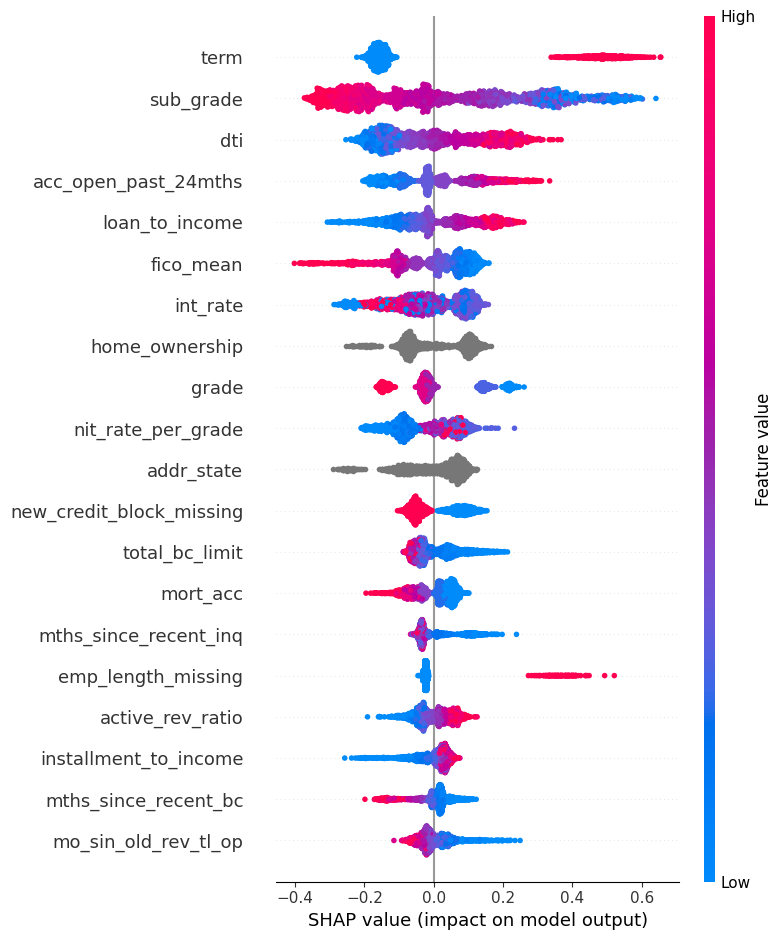

In [14]:
shap.summary_plot(
    shap_values,
    sample_X
)

In [15]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'CatBoost'
    ],
    'Accuracy': [
        0.587,
        0.682,
        0.664
    ],
    'Precision': [
        0.278,
        0.340,
        0.334
    ],
    'Recall': [
        0.667,
        0.627,
        0.688
    ],
    'F1 Score': [
        0.393,
        0.441,
        0.450
    ],
    'ROC AUC': [
        0.665,
        0.725,
        0.738
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.587,0.278,0.667,0.393,0.665
1,Random Forest,0.682,0.340,0.627,0.441,0.725
2,CatBoost,0.664,0.334,0.688,0.450,0.738


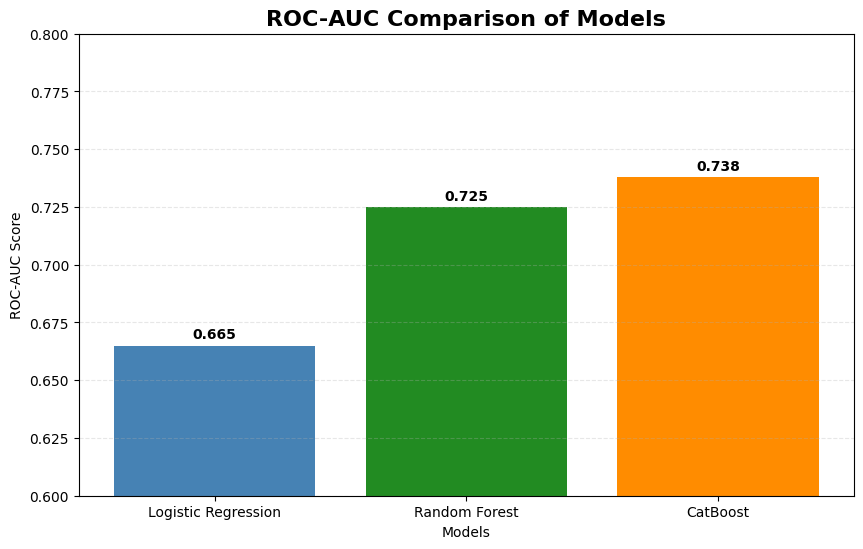

In [18]:
import matplotlib.pyplot as plt

colors = [
    '#4682B4',  # Logistic Regression
    '#228B22',  # Random Forest
    '#FF8C00'   # CatBoost
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    comparison['Model'],
    comparison['ROC AUC'],
    color=colors
)

plt.title(
    'ROC-AUC Comparison of Models',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('ROC-AUC Score')
plt.xlabel('Models')

plt.ylim(0.60, 0.80)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f'{height:.3f}',
        ha='center',
        fontweight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

In [21]:
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cat_model.get_feature_importance()
})

feat_imp = feat_imp.sort_values(
    'importance',
    ascending=False
)

feat_imp.head(20)

,feature,importance
5,sub_grade,8.975853
1,term,6.278391
98,nit_rate_per_grade,4.905223
12,dti,4.148012
2,int_rate,3.911211
4,grade,3.559395
91,loan_to_income,3.445658
90,fico_mean,3.143073
44,acc_open_past_24mths,3.088347
7,home_ownership,2.880471


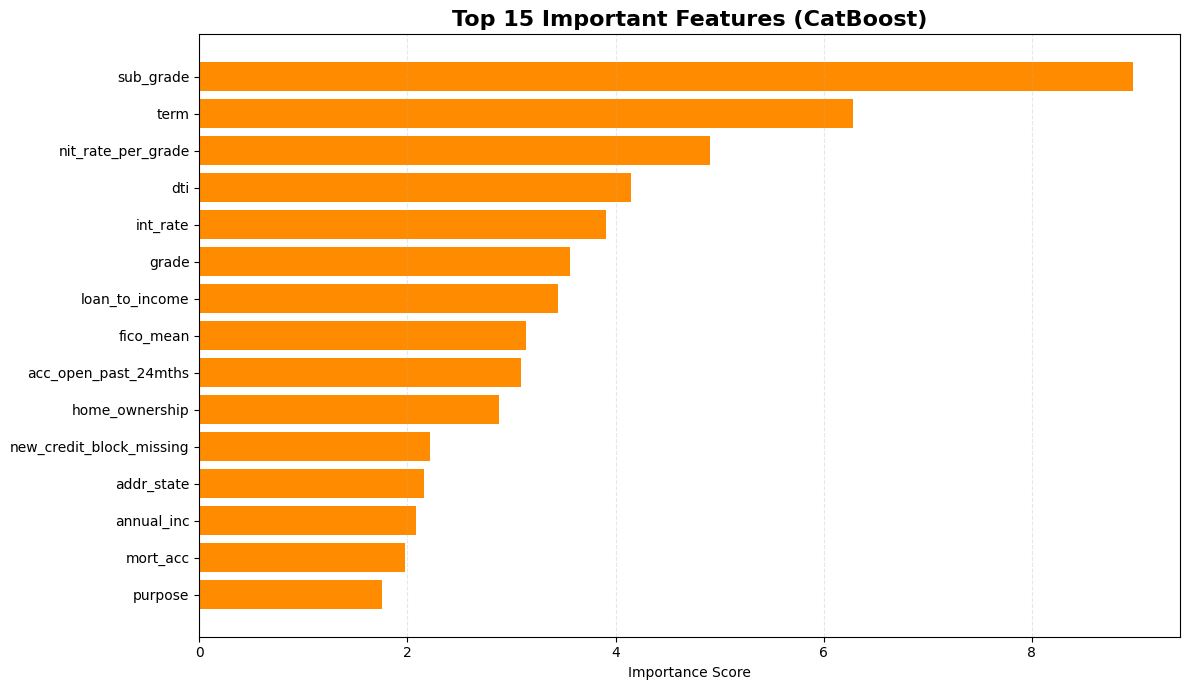

In [22]:
top_features = feat_imp.head(15)

plt.figure(figsize=(12,7))

plt.barh(
    top_features['feature'][::-1],
    top_features['importance'][::-1],
    color='#FF8C00'
)

plt.title(
    'Top 15 Important Features (CatBoost)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Importance Score')

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [24]:
feat_imp.head(15).style\
.background_gradient(cmap='YlOrBr')\
.format({'importance':'{:.3f}'})

,feature,importance
5,sub_grade,8.976
1,term,6.278
98,nit_rate_per_grade,4.905
12,dti,4.148
2,int_rate,3.911
4,grade,3.559
91,loan_to_income,3.446
90,fico_mean,3.143
44,acc_open_past_24mths,3.088
7,home_ownership,2.880


In [26]:
plt.figure(figsize=(10,6))

# your ROC chart code

plt.savefig(
    'roc_auc_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<Figure size 1000x600 with 0 Axes>

In [27]:
plt.figure(figsize=(12,7))

# feature importance code

plt.savefig(
    'feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<Figure size 1200x700 with 0 Axes>

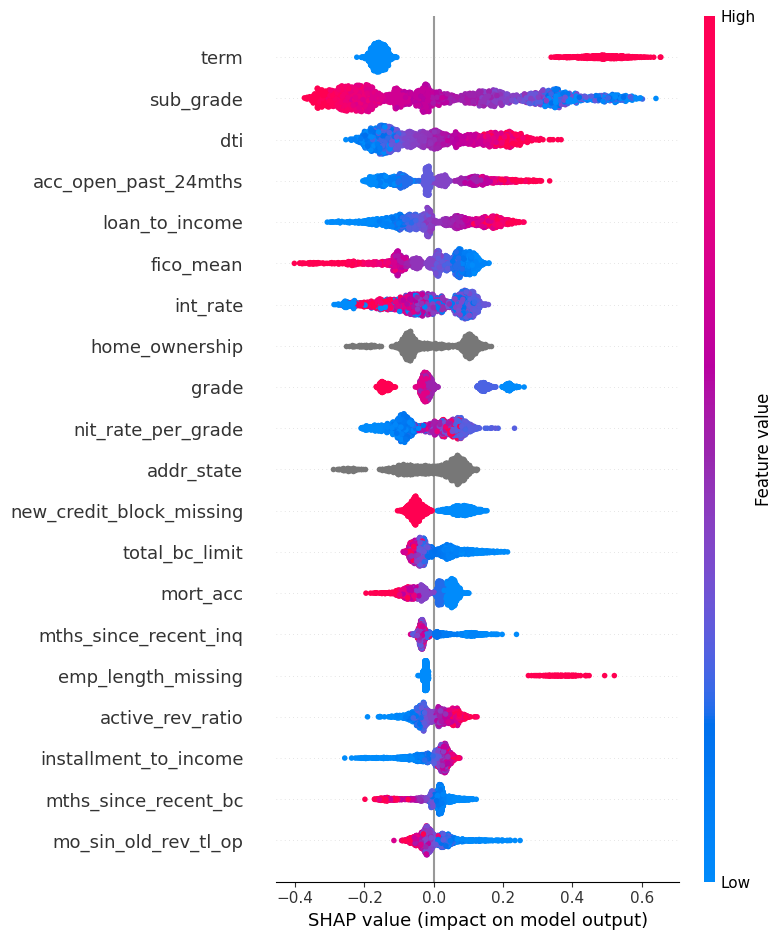

In [28]:
shap.summary_plot(
    shap_values,
    sample_X,
    show=False
)

plt.savefig(
    'shap_summary.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()